# Contrastive Learning Representation (CLR)

## Setup

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
import torch.optim as optim
from torchvision import transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn.functional as F

## Crafting data

In [ ]:
def data(c,N):
  c0, c1 = c
  x = []
  for _ in range(N):
    x1 = c0 + 1.1*np.random.randn(1).item()
    x2 = c1 + 1.1*np.random.randn(1).item()

    x.append((x1,x2))

  return x

In [ ]:
c1 = [-2.5,-2.5]
c2 = [0,0]
c3 = [2.5,2.5]

x1 = torch.tensor(data(c1,500))
x2 = torch.tensor(data(c2,500))
x3 = torch.tensor(data(c3,500))

## Data normalization

In [ ]:
X = torch.concat([x1,x2,x3])

mean = X.mean(dim=0)
std = X.std(dim=0)

x1 = (x1 - mean)/std
x2 = (x2 - mean)/std
x3 = (x3 - mean)/std

## Data visualization

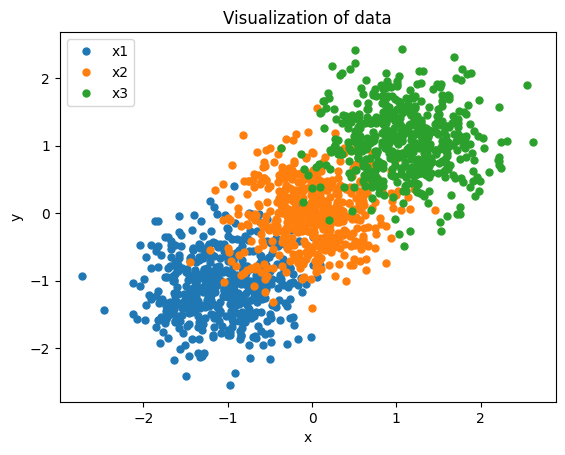

In [ ]:
plt.plot(x1[:,0],x1[:,1], linestyle="None", marker='o', markersize=5, label="x1")
plt.plot(x2[:,0],x2[:,1], linestyle="None", marker='o', markersize=5, label="x2")
plt.plot(x3[:,0],x3[:,1], linestyle="None", marker='o', markersize=5, label="x3")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Visualization of data")
plt.legend()
plt.show()

## Simple NN

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
encoder = nn.Sequential(nn.Linear(2,32), nn.ReLU(), nn.Linear(32,2))
encoder = encoder.to(device)
encoder

Sequential(
  (0): Linear(in_features=2, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=2, bias=True)
)

## Embeddings before contrastive training

In [ ]:
encoder.eval()

with torch.no_grad():
  h1_before = encoder(x1.to(device))
  h2_before = encoder(x2.to(device))
  h3_before = encoder(x3.to(device))

## Visualization of embeddings before CLR

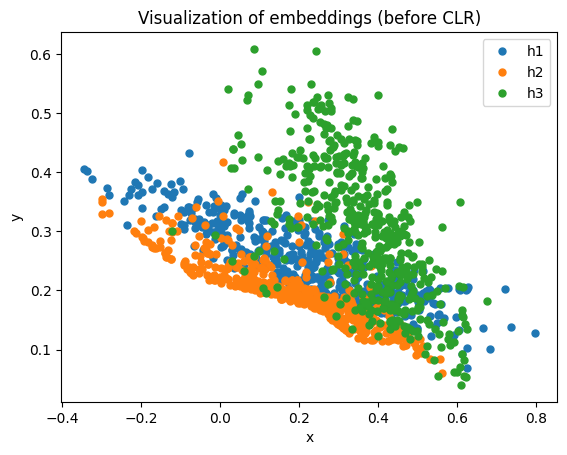

In [ ]:
plt.plot(h1_before[:,0],h1_before[:,1], linestyle="None", marker='o', markersize=5, label="h1")
plt.plot(h2_before[:,0],h2_before[:,1], linestyle="None", marker='o', markersize=5, label="h2")
plt.plot(h3_before[:,0],h3_before[:,1], linestyle="None", marker='o', markersize=5, label="h3")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Visualization of embeddings (before CLR)")
plt.legend()
plt.show()

## Dataloader

In [ ]:
transform = v2.ToDtype(torch.float32, scale=True)
X = transform(X)
X = (X - mean) / std

In [ ]:
dataloader = DataLoader(X, batch_size=64, shuffle=True)

## CLR training

In [ ]:
optimizer = optim.Adam(encoder.parameters(), lr=0.001, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
TAU = 1

encoder.train()
for _ in range(10):
  for batch, Xd in enumerate(dataloader):
      Xd = Xd.to(device)

      Xd1 = Xd + 0.4 * torch.randn_like(Xd)
      Xd2 = Xd + 0.4 * torch.randn_like(Xd)

      Z1 = F.normalize(encoder(Xd1), dim=1)
      Z2 = F.normalize(encoder(Xd2), dim=1)

      sim = Z1 @ Z2.T / TAU

      alvo = torch.arange(Z1.shape[0], device=device)
      loss = F.cross_entropy(sim, alvo)

      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

## Embeddings after contrastive training

In [ ]:
encoder.eval()

with torch.no_grad():
  h1_after = encoder(x1.to(device))
  h2_after = encoder(x2.to(device))
  h3_after = encoder(x3.to(device))

## Visualization of embeddings after CLR

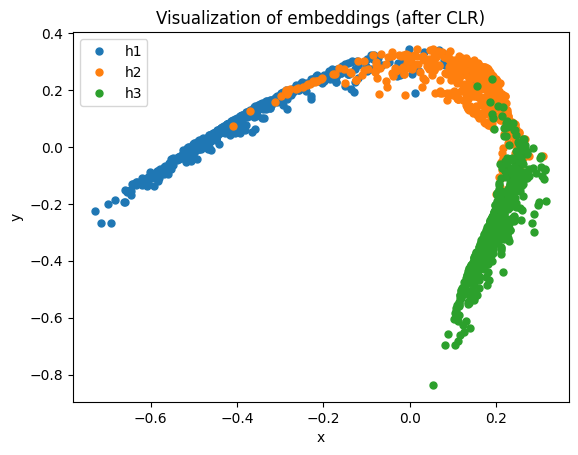

In [ ]:
plt.plot(h1_after[:,0],h1_after[:,1], linestyle="None", marker='o', markersize=5, label="h1")
plt.plot(h2_after[:,0],h2_after[:,1], linestyle="None", marker='o', markersize=5, label="h2")
plt.plot(h3_after[:,0],h3_after[:,1], linestyle="None", marker='o', markersize=5, label="h3")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Visualization of embeddings (after CLR)")
plt.legend()
plt.show()